In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
wav_path = 'train_data/0.wav'
train_df = pd.read_csv('train_data.csv')['answer'].apply(lambda x: x[1:-1])
train_df

0        967153686617
1        475237568072
2        554532815990
3      62700892530689
4       2065995398890
            ...      
295     8885008716550
296     6459814146833
297     5735698685824
298     1572821551463
299     7203147258896
Name: answer, Length: 300, dtype: str

# Plots

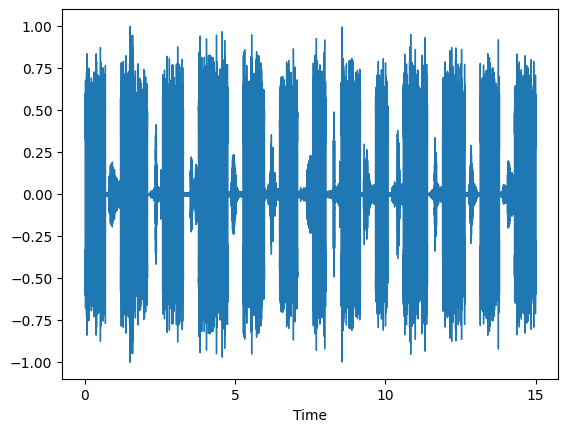

In [55]:
import librosa
SR = 48000
y, _ = librosa.load(wav_path, sr=SR)
librosa.display.waveshow(y, sr=SR)

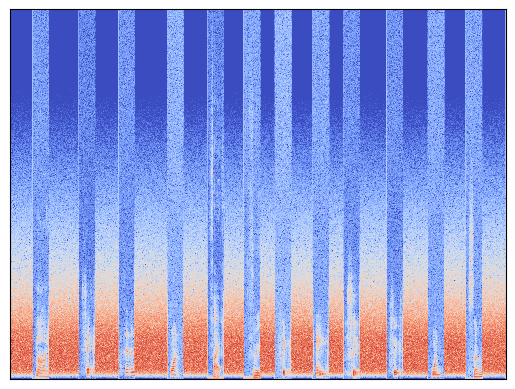

In [56]:
D = librosa.stft(y)
db = librosa.amplitude_to_db(abs(D))
librosa.display.specshow(db, sr=SR)

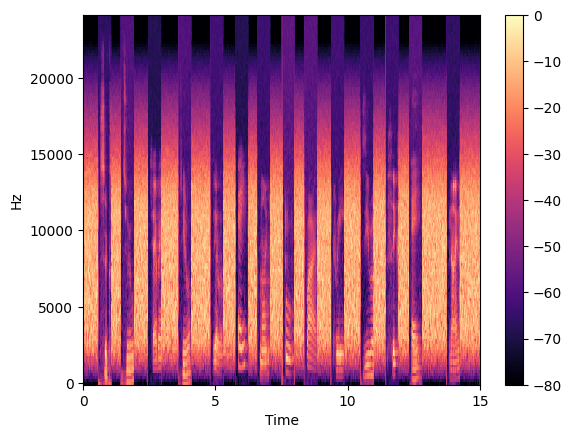

In [57]:
y, _ = librosa.load('train_data/3.wav', sr=SR)
mel = librosa.feature.melspectrogram(y=y, sr=SR)
db = librosa.power_to_db(mel, ref=np.max)
librosa.display.specshow(db, sr=SR, x_axis='time', y_axis='hz')
plt.colorbar()

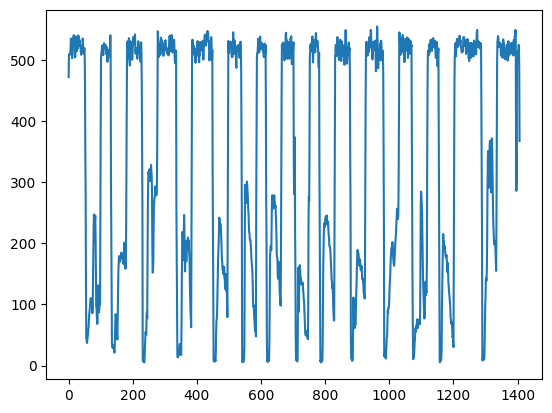

In [58]:
plt.plot(np.var(db, axis=0))

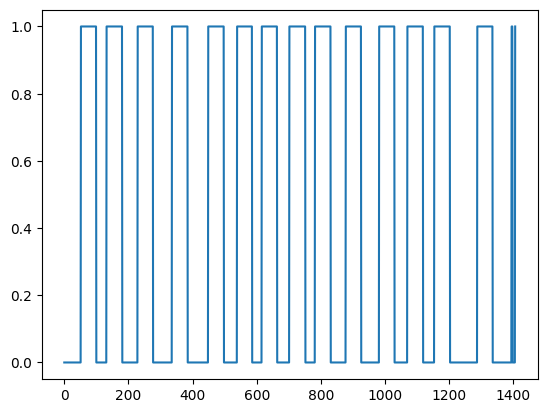

In [59]:
mel = librosa.feature.melspectrogram(y=y, sr=SR)
db = librosa.power_to_db(mel, ref=np.max)
mask = np.var(db, axis=0) < 400
plt.plot(mask)

In [60]:
masks = []
start, end = 0, 0
started = False
patiance = 0
for wav_id, bin in enumerate(mask):
    if not started and bin:
        started = True
        start = wav_id
    elif started and not bin:
        patiance+=1
        if patiance > 3:
            patiance=0
            started = False
            end = wav_id
            if end-start > 5:
                masks.append(range(start, end))

masks

[range(52, 103),
 range(132, 184),
 range(229, 280),
 range(336, 388),
 range(449, 501),
 range(539, 589),
 range(616, 667),
 range(702, 755),
 range(782, 834),
 range(878, 929),
 range(982, 1033),
 range(1070, 1122),
 range(1154, 1206),
 range(1288, 1339),
 range(1395, 1401)]

# Task

0.07666666666666666
3465


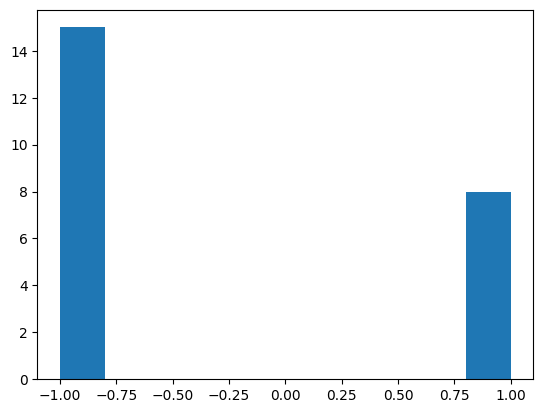

In [61]:
def get_masks(db):
    mask = np.var(db, axis=0) < 400
    masks = []
    start, end = 0, 0
    started = False
    patiance = 0
    for wav_id, bin in enumerate(mask):
        if not started and bin:
            started = True
            start = wav_id
        elif started and not bin:
            patiance+=1
            if patiance > 3:
                patiance=0
                started = False
                end = wav_id
                if end-start > 20:
                    masks.append(range(start, end))
    
    return masks

wav_files = os.listdir('train_data')
mels = []
invalid = 0
diffs = []
x_train, y_train = [], []

for wav_id, label in enumerate(train_df):
    y, _ = librosa.load(os.path.join('train_data', str(wav_id) + '.wav'), sr=SR)
    mel = librosa.feature.melspectrogram(y=y, sr=SR)
    db = librosa.power_to_db(mel, ref=np.max)
    masks = get_masks(db)
        
    if len(masks) != len(label):
        # print(f'at index {wav_id}: {len(masks)} vs {len(label)}')
        diffs.append(len(masks) - len(label))
        continue
        
    dbs = [db[:, mask] for mask in masks]
    for i, db_part in enumerate(dbs):
        x_train.append(db_part)
        y_train.append(label[i])

print(len(diffs)/300)
plt.hist(diffs)
print(len(x_train))

(array([  16.,    0.,   37.,    0.,  183.,    0., 1275.,    0., 1768.,
         125.]),
 array([48. , 48.5, 49. , 49.5, 50. , 50.5, 51. , 51.5, 52. , 52.5, 53. ]),
 <BarContainer object of 10 artists>)

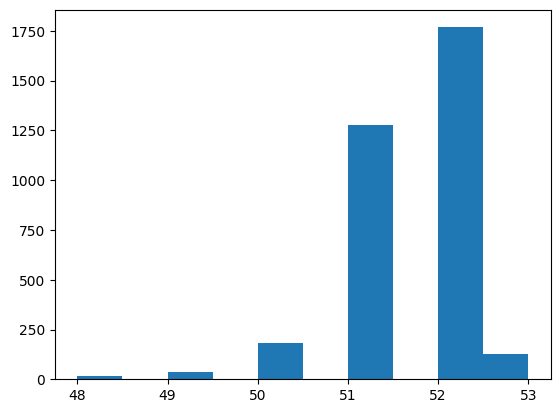

In [62]:
x_train, y_train = zip(*[(entry, label) for entry, label in zip(x_train, y_train) if entry.shape[1] > 47])
lengths = [entry.shape[1] for entry in x_train]
plt.hist(lengths)

In [63]:
x_train = [np.pad(entry, pad_width=((0,0), (0, 53-entry.shape[1])), mode='constant') for entry in x_train]

In [64]:
y_train = [int(y) for y in y_train]
y_train[0]

9

In [65]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(torch.tensor(x_train).unsqueeze(1), torch.tensor(y_train), test_size=0.1)
train_ds = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
test_ds = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=True)

C:\Users\raian\AppData\Local\Temp\ipykernel_25800\1096110264.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_ds = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
C:\Users\raian\AppData\Local\Temp\ipykernel_25800\1096110264.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_ds = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))


In [71]:
from torch import nn
import torch.nn.functional as F

class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.2)

        # input 128x53 → after pooling:
        # 128→64→32
        # 53→26→13
        self.fc = nn.Linear(6144, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [72]:
device = 'cuda'

model = SmallCNN(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    acc = correct / total
    return total_loss / len(loader), acc

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    loss_total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss_total += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    acc = correct / total
    return loss_total / len(loader), acc

In [73]:
epochs = 20

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, test_loader)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print("-" * 40)

Epoch 1/20
Train Loss: 0.7713, Train Acc: 0.7744
Val Loss: 0.3295, Val Acc: 0.8915
----------------------------------------
Epoch 2/20
Train Loss: 0.2510, Train Acc: 0.9171
Val Loss: 0.2045, Val Acc: 0.9384
----------------------------------------
Epoch 3/20
Train Loss: 0.1587, Train Acc: 0.9510
Val Loss: 0.2367, Val Acc: 0.9326
----------------------------------------
Epoch 4/20
Train Loss: 0.1126, Train Acc: 0.9638
Val Loss: 0.2080, Val Acc: 0.9472
----------------------------------------
Epoch 5/20
Train Loss: 0.0868, Train Acc: 0.9719
Val Loss: 0.2617, Val Acc: 0.9267
----------------------------------------
Epoch 6/20
Train Loss: 0.0754, Train Acc: 0.9729
Val Loss: 0.1746, Val Acc: 0.9472
----------------------------------------
Epoch 7/20
Train Loss: 0.0417, Train Acc: 0.9863
Val Loss: 0.1497, Val Acc: 0.9648
----------------------------------------
Epoch 8/20
Train Loss: 0.0307, Train Acc: 0.9902
Val Loss: 0.1820, Val Acc: 0.9677
----------------------------------------
Epoch 9/